#### Intro
> In this laboratory, you will build your own version of the K-Nearest Neighbors algorithm (a.k.a. KNN) using the NumPy library.

## LET'S REVISE THE KNN
# 1. Instance-Based Classifiers — What the hell are they?
**Brain-dead version:**
- They **don’t learn anything**.
- They **just store the training data**.
- When a new case arrives, they **look at old cases** and pick the class based on “who looks similar”.

Think:  
**“Show me your neighbors, I’ll guess your class.”**

# 2. Two Types You Need To Know
## 1. Rote-learner
- Literally a caveman.
- Only classifies if the new record is **identical** to an existing one.
- Otherwise: “idk man 🤷”.

## 2. Nearest Neighbor (k-NN)
- Smarter caveman.
- Looks at the **k closest points**.
- Your class = **majority vote of neighbors**.

That’s the one you'll actually use in labs.

# 3. What k-NN Needs
To classify a new point, k-NN needs:

### ✔ The stored training data  
(so it can compare)

### ✔ A distance metric  
Usually **Euclidean distance** for numeric features.

### ✔ A value for k  
Example:  
k = 3 → look at 3 nearest neighbors.

# 4. How k-NN Classifies a New Point
1. Compute distance between new point and **every** training point.  
2. Sort distances.  
3. Select the **k closest** ones.  
4. Look at their class labels.  
5. Pick the **majority class** → that’s your prediction.


# **What it means:**  
To classify a point **x**, look at the **k closest points** in the training set.

- If **k = 1**, only the closest point matters.  
- If **k = 2**, look at the 2 closest.  
- If **k = 3**, look at the 3 closest.  

**k-nearest neighbors = the k points with the smallest distance to x.**

That’s literally it.  
You just look around and check who’s closest.


# Nearest Neighbor Classification

### **2 steps:**



## **Step 1 — Compute distances**

Use **Euclidean distance**:

$d(p,q)=\sqrt{\sum_i (p_i - q_i)^2}$

Compute this between the new point and all training points.


## **Step 2 — Pick the class**

- Get the **k nearest neighbors**.  
- Use **majority vote** (class with most votes wins).  
- Optional improvement: **weighted vote**  

Points closer to x get more importance.

Weight formula:

$w = \frac{1}{d^2}$

**Interpretation:**  
Closer neighbors shout louder.

---

# Choosing k in KNN
- If **k is too small** → model is too sensitive to noise (one weird point can flip your prediction).
- If **k is too large** → neighborhood becomes too big and mixes points from other classes → wrong prediction.

**Rule of thumb:** small k = noisy, large k = blurry. Choose something in between.

# Scaling Issues (VERY IMPORTANT)
KNN uses distances → distances get messed up if features are on different scales.

Example:
- Height: 1.5–2.0  
- Income: 10k–1,000k  
Income dominates the distance → KNN breaks.

#### **Fix:** Normalize / standardize the features before using KNN.


# Curse of Dimensionality
- In high dimensions, **distance becomes meaningless** (all points look equally far).
- KNN performs badly when you have too many features unless you reduce dimensions.

# Evaluation of KNN
## Accuracy
- Good for simple datasets.
- Comparable to many other classifiers.

## Interpretability
- The "model" is not really interpretable.
- You can only explain a prediction by pointing to **which neighbors influenced it**.

## Incrementality
- KNN is incremental: you just add new points to the dataset.
- But you must always keep the full training set available.

## Efficiency
- No training (fast to build model).
- Classification is slow because you compute distances to **all** points.

## Scalability
- Bad scalability: prediction becomes slow with many training points.
- Suffers from the curse of dimensionality.

## Robustness
- Heavily depends on the quality of the distance metric.
- If distance is distorted (no scaling, too many dimensions), KNN collapses.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
from IPython.display import display
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# example

# ----------------------------------------
# 1. Create a tiny dummy dataset --> INPUT
# ----------------------------------------
# Features (x, y)
X = np.array([
    [1, 2],
    [2, 3],
    [3, 3],
    [6, 7],
    [7, 8],
    [8, 8]
])

# Labels --> EXPECTED OUTPUT
y = np.array(['A', 'A', 'A', 'B', 'B', 'B'])

# ----------------------------------------
# 2. Create the model (KNN with k = 3)
# ----------------------------------------
model = KNeighborsClassifier(n_neighbors=3)

# ----------------------------------------
# 3. Train the model
# ----------------------------------------
model.fit(X, y)
################################ what does it mean???? ################################
# consider this array X as input,
# for each value in the array X i'll give you the right class it belongs to y,
# train on the input X and expected output y and figure it out yourself ... do your magic and figure it out :)


# ----------------------------------------
# 4. Predict an unseen point
# ----------------------------------------
new_point = np.array([[4, 4]])

prediction = model.predict(new_point)
print(f"PREDICTION: {prediction}")

distances, indices = model.kneighbors(new_point)
# model.kneighbors(new_point) returns two things:

# A) distances
# [[1.41421356 2.23606798 3.60555128]]
# This means:
# 	•	The closest neighbor is at distance 1.4142
# 	•	The second closest is at 2.2360
# 	•	The third closest is at 3.6055
# They are ordered from smallest → largest.

# B) indices
# [[2 1 0]]
# This means the nearest neighbors are:
# 	1.	index 2
# 	2.	index 1
# 	3.	index 0
# These refer to positions in X (and y):
# Your X is:
# 0 → [1,2]
# 1 → [2,3]
# 2 → [3,3]
# 3 → [6,7]
# 4 → [7,8]
# 5 → [8,8]
# So the closest 3 points are:
# index 2 → [3,3]
# index 1 → [2,3]
# index 0 → [1,2]

print(distances, indices)
print(f"List of distances from K = 3 closest neighbours {distances} \nThese distances are respectively from the new point: {new_point} \nTo the point:\n{X} \nWith this index: {indices}")
print(f"\nSo the best distance is from {new_point} \nTo the point {X[indices[0][0]]} \nAnd the distance is {distances[0][0]}")
#print(f"For the new point {new_point} the expected class is {prediction}")
print(f"For the new point {new_point[0]} the expected class is {prediction[0]}")
print()

print("New point:", new_point)
print("Predicted class:", prediction[0])
print("3 nearest neighbors (indices):", indices[0])
print("Distances to neighbors:", distances[0])
print("Neighbor labels:", y[indices][0])

#### THIS IS SO COOL RIGHT .... BUT we won't use the K-NN with scikit-learn, we won't create a model, we don't trian or test a model, you'll have to wait for the next lab

## IN THIS LAB WE'LL IMPLEMENT K-NN THROUGH NUMPY AND PANDAS 😭😭😭😭

---

#### Datasets
- For this lab, you will need two of the datasets you have already met: Iris and MNIST.

#### 2. KNN design and implementation
- As you might remember from Lab. 1, the Iris dataset collects the measurements of different Iris flowers, and each data point is associated with a Iris species (Setosa Versicolor, or Virginica).
- In this exercise, you will **implement your own version of the the K-Nearest Neighbors algorithm**, and you will use it to assign a Iris species (i.e. a label) to flowers whose species is unknown.
- The KNN algorithm is straightforward. **Suppose that some measurements (i.e. records) and their relative species are known in advance.**
- Then, whenever we want to label a new flower, we **look at the K most similar points (a.k.a. neighbors) and assign a label accordingly.**
- The simplest solution is using a majority voting scheme: if the majority of the neighbors votes for a label, we will go for it.
- This approach is naive only at first sight: the local similarity assumed by KNN happens to be roughly true. Even though this reasoning does not generalize well1, the KNN provides a valid baseline for your tasks.

#### 1. Load the Iris dataset.

In [ ]:
DF = pd.read_csv('../../Dataset/LAB1/iris/iris.data.csv', sep=',') #it's a DataFrame

DF.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']
display(DF)

# it's already clean

#### Let’s identify a portion of our data for which we will try to guess the species. Randomly select 20% of the records and store the first four columns (i.e. the features representing each flower) into a two-dimensional numpy array of shape N ×C, you can call it X_test.

- Let’s identify a portion of our data for which we will try to guess the species --> TEST SET 
- **Randomly** select 20% of the records
- store the first four columns (all columns EXCEPT THE CLASS, which we will try to predict with KNN)
- into a two-dimensional numpy array of shape N × C --> create a matrix N is the number of rows x C is the number of columns.

ex. 5.1,3.5,1.4,0.2 ; 4.9,3.0,1.4,0.2 ; 7.0,3.2,4.7,1.4 ; 

becomes:
[[5.1,3.5,1.4,0.2], #flower per row
[4.9,3.0,1.4,0.2],
[7.0,3.2,4.7,1.4]]

- call it X_test

#### YOU'RE SELECTING A THRESGOLD, A **SAMPLE** --> .SAMPLE

# Select 20% of the data randomly as test set
DF.sample(frac=0.2, random_state=42)
- frac=0.2 --> fraction of data you want to keep
- random_state=42 --> the first time this is ran it selects a random 20%, b ut thanks to this line each time you'll run it it will always be the same random 20% --> you get the same random selection each time you run it (you can remove this for different selections every time).


#### For the same records, store the last column (i.e. the one with the species values) into another array, namely y_test. This is the data that will be used to test the accuracy of your KNN implementation and its correct functioning (i.e. the testing data).
- y_test = last column

In [ ]:
# keep 20% of the values --> test set
# keep first 4 columns (not class)
# store it in a 2 dimension numpy array

x_tt = DF.sample(frac=0.2, random_state=1)
x_t = x_tt.drop('class', axis=1)
x_test = x_t.to_numpy()      # converts the DF into a 2 dimensional numpy array (matrix)
print(x_test)

y_t = x_tt['class']
y_test = y_t.to_numpy() 
print(y_test)


# the remaining 80% is the training set
x_train = DF.drop(x_t.index)     #.index because the drop needs to know the index, to identify eactly which rows to drop


#### The one above is the way that uses fancy and obsucre functions, otherwise if you use the hint: Each pandas DataFrame stores its data as a multi-dimensional numpy array internally. You can access it through the DataFrame property values.

- less obscure and more intuitive:

In [ ]:
DS_array = DF.values

# define the number of samples you want to sample from the dataset
# keep track of the indexes you'll be extracting for the DS_array
# while the the number of extracted indexes is less than the number of samples
# generate a random index between 0 and the length of the dataset
# check if the index in question is already in the list of indexes
# if not, extract it, append it the random indexes list

n_samples = int(0.2 * len(DS_array))

rand_indexes = []
while len(rand_indexes) < n_samples:
    rnd_indx = np.random.randint(0, len(DS_array))
    if rnd_indx not in rand_indexes:
        rand_indexes.append(rnd_indx)

slice = rand_indexes
dirty_x_test = DS_array[slice]
# print(dirty_x_test) array: list of lists

# extract the last column (labels) --> indexing
y_test = dirty_x_test[:, 4]
# : --> all rows, so take all nested lists, all flowes
# 4 --> take only the last column (4th)
print(y_test)

print()

# slice the first 4 columns to get the x_train
x_test = dirty_x_test[:, 0:4]   # 4th is excluded
print(x_test)

---

#### Store the remaining 80% of the records in the same way. In this case, use the names X_train and y_train for the arrays. This is the data that your model will use as ground-truth knowledge (i.e. the training data).

In [ ]:
DS_array = DF.values

n_test_samples = int(0.2 * len(DS_array))
n_train_samples = int(len(DS_array) - n_test_samples)
# I do it in this way and not as int(0.8 * len(DS_array)), because I'm afraid one value might both in the test and training set
# int(0.8 * len(DS_array))

training_indexes = []
while len(training_indexes) < n_train_samples:
    rnd_indx = np.random.randint(0,len(DS_array))
    if rnd_indx not in training_indexes:
        training_indexes.append(rnd_indx)

dirty_x_train = DS_array[training_indexes]
# print(dirty_x_train)

x_train = dirty_x_train[:, 0:4]
y_train = dirty_x_train[:, 4]
print(x_train)
print(y_train)

---

#### The setup is done, we have all the ingredients. Now we start with the serious stuff:

####  Startingfromthenextlaboratory,youwillusethescikit-learn package. Manyofitsfunctionalities are exposed via an object-oriented interface. With this paradigm in mind, implement now the KNN algorithm and expose it as a Python class. The bare skeleton of your class should look like this (you are free to add as many methods as you want):
```python

class KNearestNeighbors:
    def __init__(self, k, distance_metric="euclidean"):
        self.k = k
        self.distance_metric = distance_metric

    def fit(self, X, y):
        """
        Store the 'prior knowledge' of your model that will be used
        to predict new labels.
        :param X: input data points, ndarray, shape = (R, C).
        :param y: input labels, ndarray, shape = (R,).
        """
        pass  # TODO: implement it!

    def predict(self, X):
        """
        Run the KNN classification on X.
        :param X: input data points, ndarray, shape = (N, C).
        :return: labels: ndarray, shape = (N,).
        """
        pass  # TODO: implement it!
```


# I do NOT know shit about class, this will be funny :)

#### ---> **Implement the fit method first**. <---
#### - Here, you should only keep track of the main attributes that will be used by the algorithm.


- In this version of the algorithm, does the KNN need to store all the samples of X_train and y_train?

```python
class KNearestNeighbors:
```
- This class will represent a KNN (K-Nearest Neighbors) model.


__init__: This is a special method in Python, known as the constructor. It’s automatically called when a new object (instance) of the class is created.
- self: This is a reference to the instance of the class itself. It’s how we access attributes and methods inside the class.
- k: This is a parameter passed when creating an instance of the class. It represents the number of neighbors (K) you want to use in KNN.
- distance_metric="euclidean": This is another parameter. It has a default value of "euclidean". It defines the distance metric to be used in KNN. You can change it to other metrics (like Manhattan) when creating the instance.

When the class is created, it stores:
- self.k: the number of neighbors
- self.distance_metric: the type of distance metric.

```python
knn_model = KNearestNeighbors(k=3, distance_metric="manhattan")
```
- This creates a new object knn_model of class KNearestNeighbors with k=3 and distance_metric="manhattan".

> The fit method (Training the model)
- In many machine learning algorithms, like linear regression or decision trees, the fit method is responsible for training the model by analyzing the data. It “learns” patterns from the data.

> But in K-Nearest Neighbors (KNN), the fit method works a bit differently:
- It does not “learn” anything from the data like in other algorithms.
- Instead, it stores the data (X and y) to use later for predictions.
- No model is built or parameters adjusted, like in traditional algorithms.

> Pass?
- In Python, pass is a placeholder. It’s used when you want to define a function or method but haven’t written the code yet, or when you need to have an empty block of code that doesn’t do anything.
- pass means “do nothing”. It’s used to keep the code syntactically correct when you haven’t yet implemented the functionality.

> Why do we use pass in the fit method?
- Since KNN does not require any training (other than just remembering the data), we don’t need to implement any actual learning process in the fit method. So, we just use pass to keep the method structure but not add any functionality yet.

> The predict method (Making predictions)
- predict: This method is used to make predictions on new, unseen data.
- X: This is the new data that you want to classify using the trained KNN model.
- return labels: The method will return an array of predicted labels for the input data X.

---

#### WORKFLOW
1.	For each point in X, you need to calculate the distance to all points in the training set (which was stored in the fit method).
> Euclidean Distance
- The Euclidean distance formula is:

$d(p, q) = \sqrt{(p_1 - q_1)^2 + (p_2 - q_2)^2 + \dots + (p_n - q_n)^2}$

Where:
- p and q are two points (flowers) with their corresponding features.
- $p_1$, $p_2$, ..., $p_n$ are the feature values of flower p.
- $q_1$, $q_2$, ..., $q_n$ are the feature values of flower q.

2.	Then, you look for the k-nearest neighbors.

3.	Finally, you predict the label based on the majority vote from these k neighbors.

In [ ]:
###############################################################################################
#        ################### fit the model --> def fit(self, x, y): ###################        
###############################################################################################







#######################################################################################
#        ################### STEP 1: CREATE DISTANCE MATRIX ###################        
#######################################################################################

stinky = False
if stinky:
    distance = np.zeros(len(x_train), dtype = float)
    for flower_1 in x_train:
        for flower_2 in x_train:
            if list(flower_1) == list(flower_2):
                continue
            distance = np.sqrt(np.sum((flower_1 - flower_2)**2))
            print(f"the distance between {flower_1} and {flower_2} is {distance}")
        
## !!!!!! BUT I have to build a distance matrix! --> I HAVE TO USE INDEXES (ENUMERATE is very useful):

option_1_distance_matrix = False
if option_1_distance_matrix:
    # Initialize distance matrix
    distance_matrix = np.zeros((len(x_train), len(x_train)), dtype=float)

    # Loop through all pairs of flowers
    for i, flower_1 in enumerate(x_train):
        for j, flower_2 in enumerate(x_train):
            if np.array_equal(flower_1, flower_2):  # Compare if the two arrays are identical
                continue
            
            # Calculate Euclidean distance if the flowers are not the same
            distance = np.sqrt(np.sum((flower_1 - flower_2) ** 2))
            
            # Store the distance in the matrix
            distance_matrix[i, j] = distance
            distance_matrix[j, i] = distance  # Since distance is symmetric

            # Print the distance between each pair of flowers
            #print(f"The distance between flower {i+1} and flower {j+1} is {distance:.2f}")

    # Print the distance matrix
    print("\nDistance Matrix:")
    print(distance_matrix)


option_2_distance_matrix = True
if option_2_distance_matrix:
    # OR if you don't like enumerate
    distance_matrix = np.zeros((len(x_train), len(x_train)), dtype=float)

    for i in range(len(x_train)):
        for j in range(len(x_train)):
            if i == j:  # Skip distance between the same flower
                continue
            
            distance = np.sqrt(np.sum((x_train[i] - x_train[j]) ** 2))
            
            distance_matrix[i, j] = distance
            distance_matrix[j, i] = distance

    print("Distance Matrix:")
    print(distance_matrix)

    # I don't like the visualization of the matrix --> heatmap of a subset matrix
    subset_matrix = distance_matrix[:10, :10]
    plt.figure(figsize=(8, 6))
    sns.heatmap(subset_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
    plt.title("Distance Matrix Heatmap")
    plt.show()

#######################################################################################
#        ################### STEP 2: SORT DISTANCE MATRIX ###################        
#######################################################################################

    # SORT THE DISTANCES, SORT THE DISTANCE MATRIX
    # from to matrix, from flower on row i to the flower on column j there's the distance X
    # the distance between flower 1 and flower 5 is 3.98

    # FIX A ROW, SO FIX A FLOWER --> FOR THAT ROW SORT THE DISTANCES
    # Sort the entire distance matrix row-wise --> axis = 1
    print(distance_matrix)
    sorted_distance_matrix_index = np.argsort(distance_matrix, axis=1)      # argsort returns indixes
    print("\nSorted Distance Matrix (indices of closest neighbors):")
    print(sorted_distance_matrix_index)

    # [[  0  97   1 ...  63 117  30]
    # [  0  97   1 ...  63 117  30]
    # ....
    # 
    # the distance between flower 0 and flower 0 is the lowest (trivial, naive),
    # the second best distance from flower 0 is the distance from flower 0 to flower 97 --> Flower 0 has its second closest neighbor as Flower 97
    # visualize the sorted indexes
    subset_matrix = sorted_distance_matrix_index[:10, :10]
    plt.figure(figsize=(8, 6))
    sns.heatmap(subset_matrix, annot=True, fmt="d",cmap='Blues', cbar=False)
    plt.title("Distance Matrix Heatmap: INDEXES")
    plt.show()
    # ignore colours, we're plotting indexes, so colours don't mean anything here as they're not values.

    # visualize the values corresponding to each index
    sorted_distance_matrix_value = np.take_along_axis(distance_matrix, sorted_distance_matrix_index, axis=1)

    subset_matrix = sorted_distance_matrix_value[:10, :10]
    plt.figure(figsize=(8, 6))
    sns.heatmap(subset_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
    plt.title("Distance Matrix Heatmap: DISTANCE VALUES")
    plt.show()
 


#### Explaination of stuff:
> What is np.argsort()?
- np.argsort() is a function in NumPy that sorts the indices of an array (or matrix), rather than the values themselves. When you call np.argsort(), it returns the indices of the sorted elements, not the sorted values.

> Can np.argsort() work directly on matrices or nested lists?
- Yes! NumPy arrays can represent both matrices and nested lists, and np.argsort() works directly on these structures.

- USE 2D ARRAYS = MATRIX, because:
- Nested List: Just a list of lists in Python. Can store any type of object, not optimized for numerical operations.
- Matrix (NumPy Array): A specialized data structure for numerical computations, optimized for performance and mathematical operations.

- In Python, matrices are usually represented as 2D arrays using NumPy, which is more efficient than using regular nested lists. NumPy arrays allow you to apply operations like np.argsort() directly on them.

> How does np.argsort() work with a matrix?
- When you have a matrix (2D array) and apply np.argsort() with axis=1, it sorts each row individually, and returns the indices that would sort the values in that row.
- For each row (flower), it returns the indices that would sort the elements in ascending order.
- In Row 0 (distances from Flower 1), the smallest distance is 0.0 (to itself), so it’s first (index 0), followed by 2.54 (index 3), 5.83 (index 1), and 6.15 (index 2).
- In Row 1 (distances from Flower 2), the smallest distance is 0.0 (to itself), so it’s first (index 1), followed by 4.72 (index 2), 5.83 (index 0), and 6.03 (index 3).
- The same sorting happens for the other rows.

## BUT
#### The lab says:
#### > Here (fit method), you should only keep track of the main attributes that will be used by the algorithm.
> Then we overdid it :)

> The lab just asked to sotre the training data and training labels

In [ ]:
class KNearestNeighbors:
    def __init__(self, k, distance_metric="euclidean"):
        self.k = k
        self.distance_metric = distance_metric

    def fit(self, x, y):
        """
        Store the 'prior knowledge' of your model that will be used
        to predict new labels.
        :param X: input data points, ndarray, shape = (R, C).
        :param y: input labels, ndarray, shape = (R,).
        """
        # x is the training set (given)
        # y is the training labels (given)
        # k is the number of neighbors

        # The lab text says:
        # 'Here, you should only keep track of the main attributes that will be used by the algorithm.'
        # You just need to store the training set and the training labels

        training_set = x
        training_labels = y

        pass  # TODO: implement it!

    def predict(self, x):
        """
        Run the KNN classification on X.
        :param X: input data points, ndarray, shape = (N, C).
        :return: labels: ndarray, shape = (N,).
        """
        pass  # TODO: implement it!


if __name__ == '__main__':
    # To create an instance of the KNearestNeighbors class, you call the class like a function and pass the required parameters to the constructor (__init__ method)
    ex_knn = KNearestNeighbors(k=3)

---

#### 5. To identify the K closest points, or neighbors, a notion of distance is required. Your implementation must support three different distance definitions.
- Given two n-dimensional points p= (p1,p2,...,pn) and q= (q1,q2,...,qn), the euclidean distance is defined as:

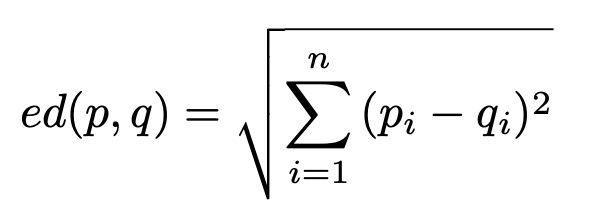



- The second distance function is the cosine distance, which is defined as:

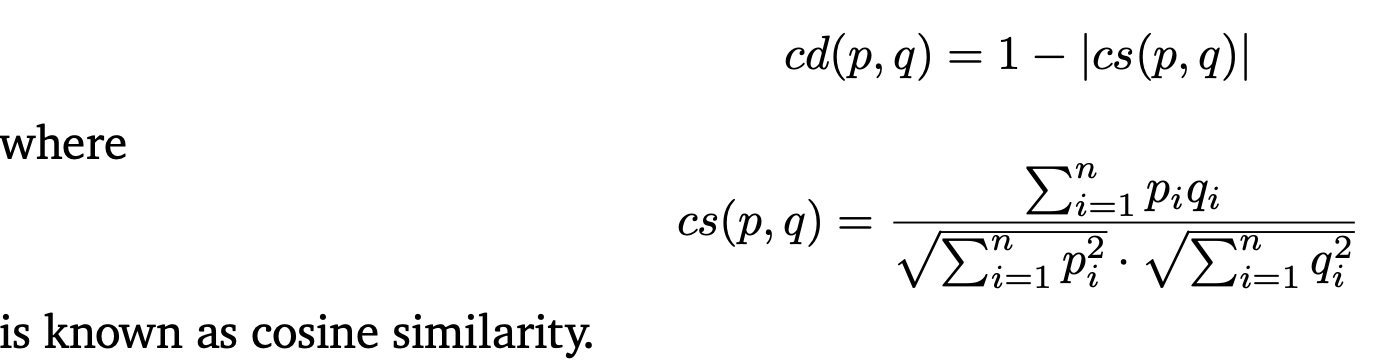



- The third distance is the Manhattan distance. The distance is defined as:

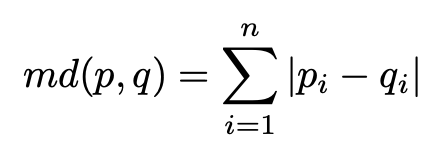



- Write three functions that receive two numpy arrays and use NumPy to compute the respective distance. As you might have noticed from the class constructor, we will use the euclidean distance by default.

# I surrender, too vague


## 1. Euclidean Distance Formula:

For two vectors p and q (with n elements), the Euclidean distance is calculated as:

**$d(p, q) = \sqrt{\sum_{i=1}^{n} (p_i - q_i)^2}$**

This means for each element `i`, you compute the squared difference between `p_i` and `q_i`, sum them up, and take the square root of the result.


## 2. Naive Method (euclidean_non_numpy):

This method iterates through each element of the two vectors, computes the squared difference for each pair, and accumulates the sum to calculate the Euclidean distance.

```python
def euclidean_non_numpy(p, q):
    cumul = 0
    for i in range(len(p)):
        cumul += (p[i] - q[i])**2
    return cumul ** 0.5
```

## 3. NumPy Method (euclidean_numpy):
- With NumPy, we can vectorize the calculation to avoid using a loop and take advantage of efficient matrix operations.
```python
def euclidean_numpy(p, q):
    return ((p - q) ** 2).sum() ** 0.5
```

Here:
- (p - q) computes the element-wise difference between the two vectors.
- ** 2 squares the differences element-wise.
- .sum() adds up the squared differences.
- ** 0.5 takes the square root of the sum to get the final Euclidean distance.

## 4. Performance Comparison:

Using timeit, the professor compared the performance of the naive method (euclidean_non_numpy) and the NumPy-based method (euclidean_numpy) on random vectors.
- The NumPy-based method is approximately 30 times faster than the naive method.

### Performance comparison with timeit
```python
time_nnp = timeit(lambda: euclidean_non_numpy(p, q), number=10000)
time_np = timeit(lambda: euclidean_numpy(p, q), number=10000)
```
---

# **VERY IMPORTANT**

## 5. Optimizing with Broadcasting:

- In the KNN context, to calculate the distance between each test point and all training points, broadcasting is used. Instead of using nested loops, broadcasting lets you efficiently compute the distance between every pair of test and training points in one go.
- First, reshape X_train so it can be broadcasted against X_test:
```python
X_train_reshaped = np.expand_dims(X_train, 1)  # Shape becomes (M, 1, n)
```

## What does np.expand_dims(X_train, 1) do?
- X_train is a 2D array (think of a table with rows and columns).
- M is the number of training samples (rows).
- n is the number of features (columns).
> For example, if X_train looks like this:
```python
X_train = [[1, 2, 3], [4, 5, 6]]
```

It has 2 rows (M = 2) and 3 columns (n = 3). So, its shape is (2, 3).
- np.expand_dims(X_train, 1) adds a new dimension. This turns your 2D array into a 3D array.
- axis=1 tells NumPy to add a new dimension between the rows and columns. So, you’re saying “add a new level between the rows and columns.”

After using np.expand_dims(X_train, 1), your X_train will look like this:
```python
X_train_reshaped = [[[1, 2, 3]], [[4, 5, 6]]]
```

The shape of this new array is (2, 1, 3). It still has 2 rows, but now each row is wrapped inside another list (an extra level of nesting), making it a 3D array.

> Why add this dimension?
- The new dimension helps with broadcasting, which is a powerful feature in NumPy.
- Broadcasting allows NumPy to automatically align two arrays of different shapes and perform operations like subtraction on them.

> Broadcasting with X_train_reshaped and X_test:
- X_train_reshaped has the shape (2, 1, 3). Each of the 2 training samples is now in a list inside a second-level list.
- X_test has the shape (3, 3). It contains 3 test samples, each with 3 features.

Now, NumPy can automatically subtract each training sample from each test sample. This is possible because of the new dimension we added to X_train_reshaped.

> Example:
- Let’s say:
- X_train = [[1, 2, 3], [4, 5, 6]]
- X_test = [[7, 8, 9], [10, 11, 12], [13, 14, 15]]

> When we use np.expand_dims(X_train, 1), we get:
```python
X_train_reshaped = [[[1, 2, 3]], [[4, 5, 6]]]
```

- The shape is now (2, 1, 3).

> Now, when we subtract X_test (which has the shape (3, 3)), NumPy broadcasts X_train_reshaped to match X_test, and the subtraction happens like this:
> First training point ([1, 2, 3]) is subtracted from all test points:
- [7, 8, 9] - [1, 2, 3], [10, 11, 12] - [1, 2, 3], [13, 14, 15] - [1, 2, 3]
- Second training point ([4, 5, 6]) is subtracted from all test points:
- [7, 8, 9] - [4, 5, 6], [10, 11, 12] - [4, 5, 6], [13, 14, 15] - [4, 5, 6]

> NumPy will automatically figure out how to align them.

> So, the result of the subtraction is a 3D array where every test point is subtracted from every training point.

## 5. Optimizing with Broadcasting:

- In the KNN context, to calculate the distance between each test point and all training points, broadcasting is used. Instead of using nested loops, broadcasting lets you efficiently compute the distance between every pair of test and training points in one go.

- **First**, reshape `X_train` so it can be broadcasted against `X_test`:

```python
X_train_reshaped = np.expand_dims(X_train, 1)  # Shape becomes (M, 1, n)
```

- Then, subtract X_test from X_train_reshaped and calculate the distance:
```python
X_diff = X_train_reshaped - X_test  # Shape (M, N, n)
dist_matrix = ((X_diff**2).sum(axis=2))**0.5  # Shape (M, N)
```

However, it makes no sense to subtract X_test from X_train, the opposite makes more sense: the distance between X_test and X_train.
- This avoids explicit loops, leveraging NumPy’s broadcasting to compute the distances between each test point and each training point efficiently.

```python
def euclidean(X_train, X_test):
    X_train_reshaped = np.expand_dims(X_train, 1)
    X_diff = X_train_reshaped - X_test
    dist_matrix = ((X_diff**2).sum(axis=2))**0.5
    return dist_matrix
```

In [ ]:
def euclidean(X_train, X_test):
    X_train_reshaped = np.expand_dims(X_train, 1)
    X_diff = X_train_reshaped - X_test
    # THIS DIFFERENCE IS THE SOLE REASON WHY WE ADDED A DIMENSION

    dist_matrix = ((X_diff**2).sum(axis=2))**.5
    return dist_matrix

# ✅ 1) Create small example matrices

### Training set → 5 samples × 5 features

```python
X_train =
[[1, 2, 3, 4, 5],
[2, 3, 4, 5, 6],
[3, 4, 5, 6, 7],
[4, 5, 6, 7, 8],
[5, 6, 7, 8, 9]]
```

- Shape: **(5, 5)**

### Test set → 2 samples × 5 features
```python
X_test =
[[10, 10, 10, 10, 10],
[ 0,  1,  0,  1,  0]]
```

- Shape: **(2, 5)**

# ❌ 2) Why subtraction FAILS without expand_dims

- Try:
> X_train - X_test

- Shapes:

(5, 5)
(2, 5)

Broadcasting rules:
- 5 vs 5 → ok  
- 5 vs 2 → ❌ cannot broadcast  
>  *(Neither dimension is 1, so NumPy cannot stretch it)*

**Result**
> ValueError: operands could not be broadcast together

# ✅ 3) Add one dimension to fix it

- We reshape:
```python
X_train_reshaped = np.expand_dims(X_train, axis=1)
```

- Now shape becomes:

(5, 1, 5)

- Let’s write it explicitly:
```python
X_train_reshaped =
[
[[1, 2, 3, 4, 5]],
[[2, 3, 4, 5, 6]],
[[3, 4, 5, 6, 7]],
[[4, 5, 6, 7, 8]],
[[5, 6, 7, 8, 9]]
]
```

- This is still the same data, but wrapped in an extra dimension.

### Why does this help?

- Now we subtract:

(5, 1, 5)
(   2, 5)

> Broadcast aligns the rightmost side:
- 5 matches 5 → ok  
- 1 stretches to 2 → ok  
- 5 stays 5 → ok  

> 🎉 Broadcasting creates:
- Result shape = (5, 2, 5)


# 🎯 4) What the subtraction ACTUALLY produces

- Let’s compute:
```python
X_diff = X_train_reshaped - X_test
```
- We subtract each training row from each test row.

### Example: first training sample

[1, 2, 3, 4, 5]

- Subtract each test sample:

- **Test #1:** `[10, 10, 10, 10, 10]`
```python
[1, 2, 3, 4, 5] - [10,10,10,10,10] =
[-9, -8, -7, -6, -5]
```

- **Test #2:** `[0, 1, 0, 1, 0]`
```python
[1, 2, 3, 4, 5] - [0,1,0,1,0] =
[1, 1, 3, 3, 5]
```

- So the first block in `X_diff` is:
```python
[
[-9, -8, -7, -6, -5],   # distance between training[0] - test[0]
[ 1,  1,  3,  3,  5]    # distance between training[0] - test[1]
]
```

- The full `X_diff` has shape:

(5 training samples, 2 test samples, 5 features)

# 🚀 5) Now compute the distance matrix

- Distance formula:
```python
distance = sqrt(sum(diff^2))
```

- So:
```python
X_diff_squared = X_diff ** 2      # shape (5, 2, 5)
sums = X_diff_squared.sum(axis=2) # shape (5, 2)
dist_matrix = np.sqrt(sums)       # shape (5, 2)
```

### Example distances for training sample #0:
- **Distance to test sample #0:**

```python
sqrt((-9)^2 + (-8)^2 + … + (-5)^2)
= sqrt(30 + 49 + … )   # numbers cut
```
```python
**Distance to test sample #1:**

sqrt(1^2 + 1^2 + 3^2 + 3^2 + 5^2)
```

---

In [ ]:
def cosine_distance(p, q):
    # ValueError: operands could not be broadcast together with shapes (4,4) (2,4) 

    p = np.expand_dims(p, 1)

    cs = (p*q) / ( (np.sum(p**2)**0.5) * (np.sum(q**2)**0.5) )
    cd = 1 - np.absolute(cs)
    return cd

# completamente sbagliata

#### completamente sbagliata, detesto le matrici, dimensioni e tutte ste cazzate dio cane

- prima: p.shape = (4, 4)
- dopo: p.shape = (4, 1, 4)
- q è x_tr → q.shape = (2, 4)

> cs = (p * q) / (...)
- p.shape = (4, 1, 4)
- q.shape = (2, 4)

> Broadcasting:
- (4, 1, 4)
- (   2, 4)

→ diventa (4, 2, 4)

- 4 = i test points
- 2 = i training points
- 4 = le 4 feature
> Fin qui ok: hai un “cubo” con tutte le combinazioni (test, train, feature).

> forse prima non lo sapevi, ma non devi fare il prodotto vettoriale p*q, ma PRODOTTO SCALARE --> p @ q
> Oppure np.dot(p, q):
- np.dot è una funzione di NumPy che calcola il prodotto scalare (o prodotto punto) di due array/vettori.
- Per due vettori p e q, il prodotto scalare è:
$\text{dot}(p, q) = p_1 \times q_1 + p_2 \times q_2 + \dots + p_n \times q_n$

- In pratica, moltiplichi i componenti corrispondenti di p e q e poi sommi il risultato
- Quindi bisogna:
1.	fare dot product → somma sui componenti

2.	poi dividere per il prodotto delle norme

- @ è un operatore che fa esattamente ciò che fa np.dot, ma in modo più elegante e compatto.

> Norme calcolate “a caso” (su tutta la matrice):
- p**2 shape (4,1,4) → np.sum(p**2) → UN SOLO numero
- q**2 shape (2,4) → np.sum(q**2) → UN SOLO numero

Quindi stai calcolando:
- una “super norma” di tutti i test messi insieme
- una “super norma” di tutti i train messi insieme

Ma cosine similarity per KNN vuole:
- ||p_i|| per ogni singolo vettore di test
- ||q_j|| per ogni singolo vettore di train

> shape della matrice risultante
- dovresti ottenere una matrice 2×4: ogni cella è “quanto è diversa” (cosine distance) un train rispetto a un test.
- Tu invece con la tua funzione ottieni shape (4, 2, 4) → completamente fuori da quello che serve a KNN.


1.	Manca il dot product: non fai la somma sulle feature → hai vettori, non scalari.

2.	Norme sbagliate: le calcoli su tutta la matrice, non per vettore.

3.	Output con shape sbagliata: KNN vuole distanze (num_train, num_test), tu restituisci (num_test, num_train, num_features).




In [ ]:
def euclidean(X_train, X_test):
    X_train_reshaped = np.expand_dims(X_train, 1) # Shape becomes (4, 1, 4)
    X_diff = X_train_reshaped - X_test  # Shape (4, 2, 4)
    # THIS DIFFERENCE IS THE SOLE REASON WHY WE ADDED A DIMENSION

    dist_matrix = ((X_diff**2).sum(axis=2))**.5 # Shape (4, 2)
    return dist_matrix


def cosine_distance(p, q):
    
    num = p @ q.T
    den_1 = np.sum(p**2, axis=1)**0.5       # take the whole p matrix, square each element, **sum on the rows (AXIS = 1)**, take the square root
    den_2 = np.sum(q**2, axis = 1)**0.5
    # problem: these fucklers are 1D arrays and I cannot multiply them together if they have different shapes
    # --> add a dimension --> from (2,) and (3,) to (2,1) and (3,1) --> so I can perform broadcasting
    # (2,1) and (3,1) to do the broadcasting I need to transpose so that I can actually perform the multiplication and therefore do the broadcasting

    den_1 = np.expand_dims(den_1, axis = 1)
    den_2 = np.expand_dims(den_2, axis = 1)
    print(den_1 * den_2.T)
    cs = num / (den_1 * den_2.T)
    cd = 1 - np.absolute(cs)

    return cd

    


def manhattan_distance (p, q):
    p_reshaped = np.expand_dims(p, axis = 1)       # 3D array (2,4) --> (2,1,4)
    difference = p_reshaped - q             # ALL rows of q are subtracted from EACH of p. shape (2,3,4)
    sum_diff = difference.sum(axis = 2)
    dm = np.absolute(sum_diff)
    return dm

if __name__ == '__main__':
    x_te = np.array([[5, 3.1, 3.0, 0.2], [5.5, 3.3, 3.1, 0.4]])
    x_tr = np.array([[4.2, 3.0, 2.0, 0], [3.2, 2.0, 1.0, 0], [2.2, 1.0, 0, 0]])
    
    # print(f"The euclidean distance between the test array {x_te} and the training array {x_tr} is {euclidean(x_te, x_tr)}")
    # print(f"The cosine distance between the test array: \n{x_te} \nand the training array: \n{x_tr} \nis {cosine_distance(x_te, x_tr)}")
    print(f"The manhattan distance between the test array: \n{x_te} \nand the training array: \n{x_tr} \nis {manhattan_distance(x_te, x_tr)}")

In [ ]:
practice = True
if practice:
    def euclidean_distance(p, q):
        p_reshaped = np.expand_dims(p, axis = 1)
        difference = p_reshaped - q
        sqr_matrix = difference**2
        sum_matrix = sqr_matrix.sum(axis = 2)
        ed = sum_matrix ** 0.5
        return ed

    if __name__ == '__main__':
        x_te = np.array([[5, 3.1, 3.0, 0.2], [5.5, 3.3, 3.1, 0.4]])
        x_tr = np.array([[4.2, 3.0, 2.0, 0], [3.2, 2.0, 1.0, 0], [2.2, 1.0, 0, 0]])
        print(euclidean_distance(x_te, x_tr))

In [ ]:
class KNearestNeighbors:
    def __init__(self, k, distance_metric="euclidean"):
        self.k = k
        self.distance_metric = distance_metric

    def fit(self, x, y):
        """
        Just store training set and training labels.
        """
        # x is the training set (given)
        # y is the training labels (given)
        # k is the number of neighbors

        # The lab text says:
        # 'Here, you should only keep track of the main attributes that will be used by the algorithm.'
        # You just need to store the training set and the training labels

        training_set = x
        training_labels = y

        pass  # TODO: implement it!

    def predict(self, x):
        """
        Run the KNN classification on X.
        :param X: input data points, ndarray, shape = (N, C).
        :return: labels: ndarray, shape = (N,).
        """
        pass  # TODO: implement it!

    def euclidean(X_train, X_test):
        X_train_reshaped = np.expand_dims(X_train, 1) # Shape becomes (4, 1, 4)
        X_diff = X_train_reshaped - X_test  # Shape (4, 2, 4)
        # THIS DIFFERENCE IS THE SOLE REASON WHY WE ADDED A DIMENSION

        dist_matrix = ((X_diff**2).sum(axis=2))**.5 # Shape (4, 2)
        return dist_matrix


    def cosine_distance(p, q):
        
        num = p @ q.T
        den_1 = np.sum(p**2, axis=1)**0.5       # take the whole p matrix, square each element, **sum on the rows (AXIS = 1)**, take the square root
        den_2 = np.sum(q**2, axis = 1)**0.5
        # problem: these fucklers are 1D arrays and I cannot multiply them together if they have different shapes
        # --> add a dimension --> from (2,) and (3,) to (2,1) and (3,1) --> so I can perform broadcasting
        # (2,1) and (3,1) to do the broadcasting I need to transpose so that I can actually perform the multiplication and therefore do the broadcasting

        den_1 = np.expand_dims(den_1, axis = 1)
        den_2 = np.expand_dims(den_2, axis = 1)
        print(den_1 * den_2.T)
        cs = num / (den_1 * den_2.T)
        cd = 1 - np.absolute(cs)

        return cd

        


    def manhattan_distance (p, q):
        p_reshaped = np.expand_dims(p, axis = 1)       # 3D array (2,4) --> (2,1,4)
        difference = p_reshaped - q             # ALL rows of q are subtracted from EACH of p. shape (2,3,4)
        sum_diff = difference.sum(axis = 2)
        dm = np.absolute(sum_diff)
        return dm



if __name__ == '__main__':
    # To create an instance of the KNearestNeighbors class, you call the class like a function and pass the required parameters to the constructor (__init__ method)
    ex_knn = KNearestNeighbors(k=3)
    

---

#### 6. Implement the predict method.
- The function receives as input a numpy array with N rows and C columns, corresponding to N flowers.
- The method assigns one of the three Iris species to each row using the KNN algorithm, and returns them as a numpy array.

- For the actual implementation, identify K neighbors using the distance specified by the parameters k and distance passed to the constructor.
- Then, assign the label using a majority voting scheme


#### workflow inside predict
1. Calcolare la matrice delle distanze

- Usi la distanza scelta (euclidean, manhattan, cosine, quello che hai scritto tu).
- Output: una matrice dist di shape (N_test, N_train) dove dist[i, j] = distanza tra test[i] e train[j].

2.	Per ogni riga (per ogni punto di test), trovare i k vicini più vicini

Per ogni riga i, cioè per ogni fiore:
- prendi dist[i] (array di lunghezza N_train)
- trovi gli indici dei k più piccoli → np.argsort(dist[i])[:self.k]
- questi indici ti dicono quali training points sono i vicini.

3. Recuperare le etichette dei vicini
- neighbor_labels = self.y_train[indices_k]

4. Majority vote (classe più frequente)
- Prendi la label che compare più spesso tra i k vicini.
- Puoi usare collections.Counter oppure farti un mini ciclo.
	
5.	Restituire un array di etichette


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
from IPython.display import display
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
class KNearestNeighbors:
    def __init__(self, k, distance_metric="euclidean"):
        self.k = k
        self.distance_metric = distance_metric

    def fit(self, x, y):
        """
        Just store training set and training labels.
        """
        # x is the training set (given)
        # y is the training labels (given)
        # k is the number of neighbors

        # The lab text says:
        # 'Here, you should only keep track of the main attributes that will be used by the algorithm.'
        # You just need to store the training set and the training labels

        # training_set = x
        # training_labels = y
        # Useless, you need to use self. to store the training set and the training labels inside the class

        self.x_train = x       # --> becomes public inside the class, every method can access it!!!!!!!!! <--
        self.y_train = y

        pass

    def euclidean(self, x_train, x_test):
        x_train_reshaped = np.expand_dims(x_train, 1) # Shape becomes (4, 1, 4)
        x_diff = x_train_reshaped - x_test  # Shape (4, 2, 4)
        # THIS DIFFERENCE IS THE SOLE REASON WHY WE ADDED A DIMENSION

        dist_matrix = ((x_diff**2).sum(axis=2))**.5 # Shape (4, 2)
        return dist_matrix

    def cosine_distance(self, p, q):
        
        num = p @ q.T
        den_1 = np.sum(p**2, axis=1)**0.5       # take the whole p matrix, square each element, **sum on the rows (AXIS = 1)**, take the square root
        den_2 = np.sum(q**2, axis = 1)**0.5
        # problem: these fuckers are 1D arrays and I cannot multiply them together if they have different shapes
        # --> add a dimension --> from (2,) and (3,) to (2,1) and (3,1) --> so I can perform broadcasting
        # (2,1) and (3,1) to do the broadcasting I need to transpose so that I can actually perform the multiplication and therefore do the broadcasting

        den_1 = np.expand_dims(den_1, axis = 1)
        den_2 = np.expand_dims(den_2, axis = 1)
        print(den_1 * den_2.T)
        cs = num / (den_1 * den_2.T)
        cd = 1 - np.absolute(cs)

        return cd

    def manhattan_distance (self, p, q):
        p_reshaped = np.expand_dims(p, axis = 1)       # 3D array (2,4) --> (2,1,4)
        difference = p_reshaped - q             # ALL rows of q are subtracted from EACH of p. shape (2,3,4)
        sum_diff = difference.sum(axis = 2)
        dm = np.absolute(sum_diff)
        return dm
    
    def predict(self, x_test):
        """
        Run the KNN classification on X.
        :param X: input data points, ndarray, shape = (N, C).
        :return: labels: ndarray, shape = (N,).
        """
        
        # STEP 1: compute the distance matrix between text_set (x) and train_set
        distance_matrix = self.euclidean(self.x_train, x_test)
        # in this way the matrix has shape (n_train, n_test) --> ma per classificare i test point è meglio averli sulle righe --> rovescia la matrice, trasponila
        distance_matrix = distance_matrix.T
        # print(distance_matrix)

        # STEP 2: sort per row
        sorted_idx = np.argsort(distance_matrix)  # get the indexes

        # STEP 3: find k nearest neighbours
        k_nearest = sorted_idx[:, :self.k]
        
        # STEP 4: find the corresponding labels to the argsort indexes
        k_nearest_classes = self.y_train[k_nearest]
        
        # STEP 5: assign class based on a majority vote
        predictions = []

        for row in k_nearest_classes:
            values, counts = np.unique(row, return_counts=True)     # ex. values = ["SETOSA", "VERSICOLOR"] ; counts = [2, 1]
            max_idx = np.argmax(counts)
            majority_label = values[max_idx]
            predictions.append(majority_label)

        predictions = np.array(predictions)
        
        return predictions


                
if __name__ == '__main__':
    # import csv file
    DF = pd.read_csv('../..Dataset/LAB1/iris/iris.data.csv', sep=',') #it's a DataFrame
    DF.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']

    # get test set, values and labels
    x_test_dirty = DF.sample(frac=0.2, random_state=1)
    x_t = x_test_dirty.drop('class', axis=1)
    x_test = x_t.to_numpy()      # converts the DF into a 2 dimensional numpy array (matrix)
    y_t = x_test_dirty['class']
    y_test = y_t.to_numpy()

    # the remaining 80% is the training set
    x_train_dirty = DF.drop(x_t.index)
    x_train = x_train_dirty.drop('class', axis=1)
    x_train = x_train.to_numpy()
    y_train = x_train_dirty['class']
    y_train = y_train.to_numpy()

    # create KNearestNeighbors object
    k = 3
    knn = KNearestNeighbors(k)
    knn.fit(x_train, y_train)
    predictions = knn.predict(x_test)

    # print(f"\nThe model uses this data to perform the KNN. \n\nTraining set: \n{x_train} \n\nTraining labels: \n{y_train}")
    # print(f"\n\nWe want to predict this data class with K = {k}: \n{x_test}")
    # print(f"\n\nThe predictions are: \n{predictions}")

    # visulize properly
    for idx in range(len(x_test)):
        print(f"\nThe prediction for the flower {x_test[idx]} is {predictions[idx]}")


In [ ]:
class KNearestNeighbors:
    def __init__(self, k, distance_metric="euclidean"):
        self.k = k
        self.distance_metric = distance_metric

    def fit(self, x, y):
        """
        Just store training set and training labels.
        """
        self.x_train = x       # --> self. becomes public inside the class, every method can access it!!!!!!!!! <--
        self.y_train = y

    def euclidean(self, x_train, x_test):
        """
        Compute the Euclidean distance between two points.
        :param x_train: training set, ndarray, shape = (N, C).
        :param x_test: test set, ndarray, shape = (N, C).
        :return: dist_matrix: ndarray, shape = (N, N).

        step 1: reshape x_train and x_test to have shape (N, 1, C), adding a new dimension = 3D array
        x_train_reshaped
        --> to perform the subtraction using broadcasting
        --> allows to fix x_train row and subtract each row of x_test
        (should be the opposite, but I'm dumb and lazy to fix it, I'll compute this and just traspose it) 
        
        step 2: compute the euclidean distance
        """

        x_train_reshaped = np.expand_dims(x_train, 1)
        x_diff = x_train_reshaped - x_test
        
        dist_matrix = ((x_diff**2).sum(axis=2))**.5
        return dist_matrix

    def cosine_distance(self, p, q):
        
        num = p @ q.T
        den_1 = np.sum(p**2, axis=1)**0.5
        den_2 = np.sum(q**2, axis = 1)**0.5
        
        den_1 = np.expand_dims(den_1, axis = 1)
        den_2 = np.expand_dims(den_2, axis = 1)
        cs = num / (den_1 * den_2.T)
        cd = 1 - np.absolute(cs)

        return cd

    def manhattan_distance (self, p, q):
        p_reshaped = np.expand_dims(p, axis = 1)       
        difference = p_reshaped - q            
        sum_diff = difference.sum(axis = 2)
        dm = np.absolute(sum_diff)
        return dm
    
    def predict(self, x_test):
        """
        Run the KNN classification on X.
        :param X: input data points, ndarray, shape = (N, C).
        :return: labels: ndarray, shape = (N,).
        """
        
        # STEP 1: compute the distance matrix between text_set (x) and train_set
        distance_matrix = self.euclidean(self.x_train, x_test)
        # in this way the matrix has shape (n_train, n_test) --> to clissify test point I want test points on rows --> turn it upside down, transpose it
        distance_matrix = distance_matrix.T

        # STEP 2: sort per row
        sorted_idx = np.argsort(distance_matrix)  # get the indexes

        # STEP 3: find k nearest neighbours
        k_nearest = sorted_idx[:, :self.k]
        
        # STEP 4: find the corresponding labels to the argsort indexes
        k_nearest_classes = self.y_train[k_nearest]
        
        # STEP 5: assign class based on a majority vote
        predictions = []

        for row in k_nearest_classes:
            values, counts = np.unique(row, return_counts=True)     # ex. values = ["SETOSA", "VERSICOLOR"] ; counts = [2, 1]
            max_idx = np.argmax(counts)
            majority_label = values[max_idx]
            predictions.append(majority_label)

        predictions = np.array(predictions)
        
        return predictions

# read CSV file + create DF
def import_cvs_file (file_path):
    DF = pd.read_csv(file_path, sep=',') #it's a DataFrame
    DF.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']
    return DF
    
# ignore
# a way to get training data
def training_data(DF):
    x_test_dirty = DF.sample(frac=0.2, random_state=1)
    x_t = x_test_dirty.drop('class', axis=1)
    x_test = x_t.to_numpy()      # converts the DF into a 2 dimensional numpy array (matrix)
    y_t = x_test_dirty['class']
    y_test = y_t.to_numpy()

# get test and train data
def get_test_and_train_data(DF):
    DF_shuffled = DF.sample(frac=1, random_state=1) # escamotage to only shuffle the data --> returns all rows, but shuffled.

    # --- 2. Compute split size ---
    n_total = len(DF_shuffled)
    n_test = int(0.2 * n_total)

    # --- 3. Split the dataframe into test and train ---
    test_df = DF_shuffled.iloc[:n_test]
    train_df = DF_shuffled.iloc[n_test:]

    # --- 4. Extract test data x and test labes y ---
    x_test = test_df.drop('class', axis=1).to_numpy()
    y_test = test_df['class'].to_numpy()

    # --- 5. Extract train data x and train labels y ---
    x_train = train_df.drop('class', axis=1).to_numpy()
    y_train = train_df['class'].to_numpy()
    return x_test, y_test, x_train, y_train


if __name__ == '__main__':
    # import csv file
    DF = import_cvs_file('../../Dataset/LAB1/iris/iris.data.csv')

    # get train data and test data
    x_test, y_test, x_train, y_train = get_test_and_train_data(DF)

    # create KNearestNeighbors object
    k = 3
    knn = KNearestNeighbors(k)
    knn.fit(x_train, y_train)
    predictions = knn.predict(x_test)

    # print(f"\nThe model uses this data to perform the KNN. \n\nTraining set: \n{x_train} \n\nTraining labels: \n{y_train}")
    # print(f"\n\nWe want to predict this data class with K = {k}: \n{x_test}")
    # print(f"\n\nThe predictions are: \n{predictions}")

    # visulize properly
    for idx in range(len(x_test)):
        print(f"\nThe prediction for the flower {x_test[idx]} is {predictions[idx]}")

---

#### Now let’s fit the KNN model with the X_train and y_train data. Then, try to use your KNN model to predict the species for each record in X_test and store them in a nupy array called y_pred.
- *"Now let’s fit the KNN model with the X_train and y_train data"* = glue all the pieces together and see if it works
- *Then, try to use your KNN model to predict the species for each record in X_test and store them in a nupy array called y_pred*
> predict the species for each flower in x_test

> store those predicted classes in an array: y_pred

- *Check how many Iris species in the array y_pred have been guessed correctly with respect to the ones in y_test.*
- *A prediction is correct if y_pred[i] == y_test[i]*

- *The ratio between the number of correct guesses and the total number of guesses is known as **accuracy**.*


- *If all labels are assigned correctly ((y_pred == y_test).all() == True), the accuracy of the model is 100%.*
- Instead, if none of the guessed species corresponds to the real one ((y_pred == y_test).any() == False), the accuracy is 0%.

In [ ]:
class KNearestNeighbors:
    def __init__(self, k, distance_metric="euclidean"):
        self.k = k
        self.distance_metric = distance_metric

    def fit(self, x, y):
        """
        Just store training set and training labels.
        """
        self.x_train = x       # --> self. becomes public inside the class, every method can access it!!!!!!!!! <--
        self.y_train = y

    def euclidean(self, x_train, x_test):
        """
        Compute the Euclidean distance between two points.
        :param x_train: training set, ndarray, shape = (N, C).
        :param x_test: test set, ndarray, shape = (N, C).
        :return: dist_matrix: ndarray, shape = (N, N).

        step 1: reshape x_train and x_test to have shape (N, 1, C), adding a new dimension = 3D array
        x_train_reshaped
        --> to perform the subtraction using broadcasting
        --> allows to fix x_train row and subtract each row of x_test
        (should be the opposite, but I'm dumb and lazy to fix it, I'll compute this and just traspose it) 
        
        step 2: compute the euclidean distance
        """

        x_train_reshaped = np.expand_dims(x_train, 1)
        x_diff = x_train_reshaped - x_test
        
        dist_matrix = ((x_diff**2).sum(axis=2))**.5
        return dist_matrix
    
    def predict(self, x_test):
        """
        Run the KNN classification on X.
        :param X: input data points, ndarray, shape = (N, C).
        :return: labels: ndarray, shape = (N,).
        """
        
        # STEP 1: compute the distance matrix between text_set (x) and train_set
        distance_matrix = self.euclidean(self.x_train, x_test)
        # in this way the matrix has shape (n_train, n_test) --> to clissify test point I want test points on rows --> turn it upside down, transpose it
        distance_matrix = distance_matrix.T

        # STEP 2: sort per row
        sorted_idx = np.argsort(distance_matrix)  # get the indexes

        # STEP 3: find k nearest neighbours
        k_nearest = sorted_idx[:, :self.k]
        
        # STEP 4: find the corresponding labels to the argsort indexes
        k_nearest_classes = self.y_train[k_nearest]
        
        # STEP 5: assign class based on a majority vote
        predictions = []

        for row in k_nearest_classes:
            values, counts = np.unique(row, return_counts=True)     # ex. values = ["SETOSA", "VERSICOLOR"] ; counts = [2, 1]
            max_idx = np.argmax(counts)
            majority_label = values[max_idx]
            predictions.append(majority_label)

        predictions = np.array(predictions)
        
        return predictions

# read CSV file + create DF
def import_cvs_file (file_path):
    DF = pd.read_csv(file_path, sep=',') #it's a DataFrame
    DF.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']
    return DF

# get test and train data
def get_test_and_train_data(DF):
    DF_shuffled = DF.sample(frac=1, random_state=1) # escamotage to only shuffle the data --> returns all rows, but shuffled.

    # --- 2. Compute split size ---
    n_total = len(DF_shuffled)
    n_test = int(0.2 * n_total)

    # --- 3. Split the dataframe into test and train ---
    test_df = DF_shuffled.iloc[:n_test]
    train_df = DF_shuffled.iloc[n_test:]

    # --- 4. Extract test data x and test labes y ---
    x_test = test_df.drop('class', axis=1).to_numpy()
    y_test = test_df['class'].to_numpy()

    # --- 5. Extract train data x and train labels y ---
    x_train = train_df.drop('class', axis=1).to_numpy()
    y_train = train_df['class'].to_numpy()
    return x_test, y_test, x_train, y_train


if __name__ == '__main__':
    # import csv file
    DF = import_cvs_file('../../Dataset/LAB1/iris/iris.data.csv')

    # get train data and test data
    x_test, y_test, x_train, y_train = get_test_and_train_data(DF)

    # create KNearestNeighbors object
    k = 3
    knn = KNearestNeighbors(k)
    knn.fit(x_train, y_train)
    predictions = knn.predict(x_test)

    # visulize properly
    # for idx in range(len(x_test)):
    #     print(f"\nThe prediction for the flower {x_test[idx]} is {predictions[idx]}")
    
    y_pred = knn.predict(x_test)

    # compute accuracy
    count = 0
    for idx in range(len(y_pred)):
        # print(f"\n\nGuessed class: {y_pred[idx]} \nActual class: {y_test[idx]}")
        if y_pred[idx] == y_test[idx]:
            count += 1
        else:
            print(f"\n\nGuessed class: {y_pred[idx]} \nActual class: {y_test[idx]}")
    accuracy = count / len(y_test)
    print(f"Accuracy: {accuracy} %")

## I'll skip these, do them if you'll have time
8. (*) As a software developer, you might want to increase the functionalities of your product and
publish newer versions over time. The better your code is structured and organized, the lower the
effort to release updates.
As such, extend now your KNN implementation by adding the parameter weights to the constructor,
as shown below:
class K N e a r e s t N e i g h b o r s :
def __init__ ( self , k , d i s t a n c e _ m e t r i c = " euclidean " , weights = "
uniform " ) :
self . k = k
self . d i s t a n c e _ m e t r i c = d i s t a n c e _ m e t r i c
self . weights = weights
Change your KNN implementation to accept a new weighting scheme for the labels. If weights=
"distance", weight neighbor votes by the inverse of their distance (for the distance, again, use
distance_metric). The weight for a neighbor of the point p is:
w(p,n) = 1 / distance_metric(p, n)

Instead, if the default is chosen (weights="uniform"), use the majority voting you already imple-
mented in Exercise 6.

9. (*) Test the modularity of the implementation applying it on a different dataset. Ideally, you should
not change the code of your KNN python class.
• Download the MNIST dataset and sample only 100 points per digit. You will end up with a
dataset of 1000 samples.
• Define again four numpy arrays as you did in Exercises 2 and 3.
• Apply your KNN as you did for the Iris dataset.
• Evaluate the accuracy on MNIST’s y_test.

10. (*) The choice of parameters like k, distance_metric or weights is part of your data analysis
pipeline: theprocessistypicallyknownasvalidation. Youwilllearnmoreaboutalgorithmvalidation
in theory lectures.
For now, evaluate the accuracy scores achieved by your KNN with different parameter values. Then,
try to identify which is the best configuration, for both Iris and MNIST.

---

---